<a href="https://colab.research.google.com/github/Sourabhkaverappa15/ML-project-1/blob/main/sonar_rock_vs_mine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

## Data Collection and processing

In [6]:
#loading data
sonardata=pd.read_csv("/content/sonar data.csv",header=None)

In [7]:
sonardata.head()

,0,1,2,3,4,5,6,7,8,9,...,51,52,53,54,55,56,57,58,59,60
0,0.0200,0.0371,0.0428,0.0207,0.0954,0.0986,0.1539,0.1601,0.3109,0.2111,...,0.0027,0.0065,0.0159,0.0072,0.0167,0.0180,0.0084,0.0090,0.0032,R
1,0.0453,0.0523,0.0843,0.0689,0.1183,0.2583,0.2156,0.3481,0.3337,0.2872,...,0.0084,0.0089,0.0048,0.0094,0.0191,0.0140,0.0049,0.0052,0.0044,R
2,0.0262,0.0582,0.1099,0.1083,0.0974,0.2280,0.2431,0.3771,0.5598,0.6194,...,0.0232,0.0166,0.0095,0.0180,0.0244,0.0316,0.0164,0.0095,0.0078,R
3,0.0100,0.0171,0.0623,0.0205,0.0205,0.0368,0.1098,0.1276,0.0598,0.1264,...,0.0121,0.0036,0.0150,0.0085,0.0073,0.0050,0.0044,0.0040,0.0117,R
4,0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,...,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094,R


In [8]:
#number of rows and columns
sonardata.shape


(208, 61)

In [9]:
sonardata.describe()


,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,...,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,0.029164,0.038437,0.043832,0.053892,0.075202,0.104570,0.121747,0.134799,0.178003,0.208259,...,0.016069,0.013420,0.010709,0.010941,0.009290,0.008222,0.007820,0.007949,0.007941,0.006507
std,0.022991,0.032960,0.038428,0.046528,0.055552,0.059105,0.061788,0.085152,0.118387,0.134416,...,0.012008,0.009634,0.007060,0.007301,0.007088,0.005736,0.005785,0.006470,0.006181,0.005031
min,0.001500,0.000600,0.001500,0.005800,0.006700,0.010200,0.003300,0.005500,0.007500,0.011300,...,0.000000,0.000800,0.000500,0.001000,0.000600,0.000400,0.000300,0.000300,0.000100,0.000600
25%,0.013350,0.016450,0.018950,0.024375,0.038050,0.067025,0.080900,0.080425,0.097025,0.111275,...,0.008425,0.007275,0.005075,0.005375,0.004150,0.004400,0.003700,0.003600,0.003675,0.003100
50%,0.022800,0.030800,0.034300,0.044050,0.062500,0.092150,0.106950,0.112100,0.152250,0.182400,...,0.013900,0.011400,0.009550,0.009300,0.007500,0.006850,0.005950,0.005800,0.006400,0.005300
75%,0.035550,0.047950,0.057950,0.064500,0.100275,0.134125,0.154000,0.169600,0.233425,0.268700,...,0.020825,0.016725,0.014900,0.014500,0.012100,0.010575,0.010425,0.010350,0.010325,0.008525
max,0.137100,0.233900,0.305900,0.426400,0.401000,0.382300,0.372900,0.459000,0.682800,0.710600,...,0.100400,0.070900,0.039000,0.035200,0.044700,0.039400,0.035500,0.044000,0.036400,0.043900


In [10]:
sonardata[60].value_counts()



,count
60,
M,111
R,97


grouping by m and r

In [11]:
sonardata.groupby(60).mean()

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
60,,,,,,,,,,,,,,,,,,,,,
M,0.034989,0.045544,0.050720,0.064768,0.086715,0.111864,0.128359,0.149832,0.213492,0.251022,...,0.019352,0.016014,0.011643,0.012185,0.009923,0.008914,0.007825,0.009060,0.008695,0.006930
R,0.022498,0.030303,0.035951,0.041447,0.062028,0.096224,0.114180,0.117596,0.137392,0.159325,...,0.012311,0.010453,0.009640,0.009518,0.008567,0.007430,0.007814,0.006677,0.007078,0.006024


In [12]:
#separate data and labels
x=sonardata.drop(columns=60,axis=1)
y=sonardata[60]

Text(0.5, 1.0, 'Scatter plot of Feature 0 vs Target')

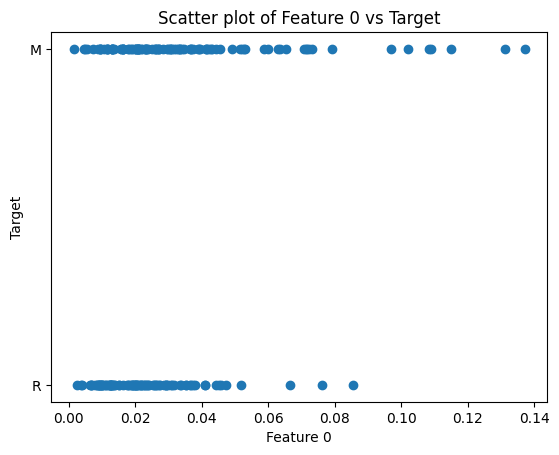

In [27]:
plt.scatter(x.iloc[:, 0], y)
plt.xlabel('Feature 0')
plt.ylabel('Target')
plt.title('Scatter plot of Feature 0 vs Target')

In [14]:
y

,60
0,R
1,R
2,R
3,R
4,R
...,...
203,M
204,M
205,M
206,M


training and test data


In [15]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1, stratify=y, random_state=1)
 #stratify splits m and r equally into test and train

In [16]:
x_train

,0,1,2,3,4,5,6,7,8,9,...,50,51,52,53,54,55,56,57,58,59
115,0.0414,0.0436,0.0447,0.0844,0.0419,0.1215,0.2002,0.1516,0.0818,0.1975,...,0.0222,0.0045,0.0136,0.0113,0.0053,0.0165,0.0141,0.0077,0.0246,0.0198
38,0.0123,0.0022,0.0196,0.0206,0.0180,0.0492,0.0033,0.0398,0.0791,0.0475,...,0.0149,0.0125,0.0134,0.0026,0.0038,0.0018,0.0113,0.0058,0.0047,0.0071
56,0.0152,0.0102,0.0113,0.0263,0.0097,0.0391,0.0857,0.0915,0.0949,0.1504,...,0.0048,0.0049,0.0041,0.0036,0.0013,0.0046,0.0037,0.0011,0.0034,0.0033
123,0.0270,0.0163,0.0341,0.0247,0.0822,0.1256,0.1323,0.1584,0.2017,0.2122,...,0.0197,0.0189,0.0204,0.0085,0.0043,0.0092,0.0138,0.0094,0.0105,0.0093
18,0.0270,0.0092,0.0145,0.0278,0.0412,0.0757,0.1026,0.1138,0.0794,0.1520,...,0.0045,0.0084,0.0010,0.0018,0.0068,0.0039,0.0120,0.0132,0.0070,0.0088
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,0.0412,0.1135,0.0518,0.0232,0.0646,0.1124,0.1787,0.2407,0.2682,0.2058,...,0.0798,0.0376,0.0143,0.0272,0.0127,0.0166,0.0095,0.0225,0.0098,0.0085
5,0.0286,0.0453,0.0277,0.0174,0.0384,0.0990,0.1201,0.1833,0.2105,0.3039,...,0.0104,0.0045,0.0014,0.0038,0.0013,0.0089,0.0057,0.0027,0.0051,0.0062
154,0.0117,0.0069,0.0279,0.0583,0.0915,0.1267,0.1577,0.1927,0.2361,0.2169,...,0.0039,0.0053,0.0029,0.0020,0.0013,0.0029,0.0020,0.0062,0.0026,0.0052
131,0.1150,0.1163,0.0866,0.0358,0.0232,0.1267,0.2417,0.2661,0.4346,0.5378,...,0.0228,0.0099,0.0065,0.0085,0.0166,0.0110,0.0190,0.0141,0.0068,0.0086


In [ ]:
scatter

In [17]:
#model training

model=LogisticRegression()

model.fit(x_train,y_train)

LogisticRegression()

Model evaluation


In [23]:
#prediction on test data
y_predict=model.predict(x_test)

train_accuracy=accuracy_score(y_test,y_predict)

print(train_accuracy)

0.7619047619047619


In [24]:
#prediction on train data
y_predict_train=model.predict(x_train)

test_accuracy=accuracy_score(y_train,y_predict_train)

print(test_accuracy)

0.8342245989304813


In [ ]:
plt.scatter(x.iloc[:, 0], y)
plt.

In [28]:
plt.clf()

<Figure size 640x480 with 0 Axes>

### Plotting the Logistic Regression Curve for 'Feature 0'

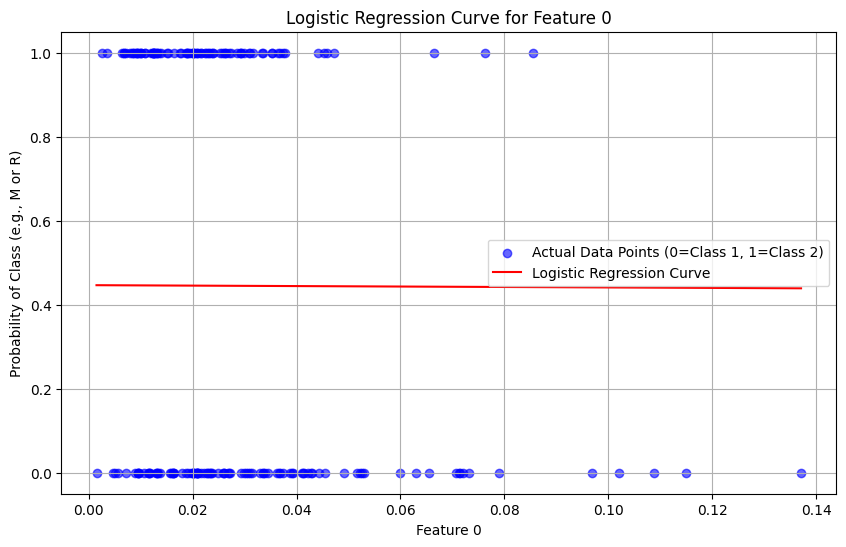

In [29]:
# Map 'R' and 'M' to numerical values (e.g., 0 and 1) for plotting
y_train_numeric = y_train.map({model.classes_[0]: 0, model.classes_[1]: 1})

# Create a range of values for 'Feature 0' for smooth curve plotting
feature_0_range = np.linspace(x_train.iloc[:, 0].min(), x_train.iloc[:, 0].max(), 300)

# Create a dummy DataFrame for prediction. Set 'Feature 0' to the range, and other features to their mean.
x_plot = pd.DataFrame(np.tile(x_train.mean().values, (len(feature_0_range), 1)), columns=x_train.columns)
x_plot.iloc[:, 0] = feature_0_range

# Predict probabilities for the 'M' class (assuming it's the second class in model.classes_)
# Adjust index based on model.classes_ to get the desired class probability
# For example, if model.classes_ is ['M', 'R'], then predict_proba[:, 0] is for 'M'
# If model.classes_ is ['R', 'M'], then predict_proba[:, 1] is for 'M'
# Let's assume model.classes_ maps the first class (index 0) to 0 and the second class (index 1) to 1 for the numeric labels.
# We will plot the probability of the class that corresponds to 1 in y_train_numeric.

prob_index = 1 if model.classes_[1] == y_train.unique()[np.where(y_train_numeric == 1)[0][0]] else 0
predicted_probabilities = model.predict_proba(x_plot)[:, prob_index]

plt.figure(figsize=(10, 6))

# Plot original scatter points
plt.scatter(x_train.iloc[:, 0], y_train_numeric, color='blue', label='Actual Data Points (0=Class 1, 1=Class 2)', alpha=0.6)

# Plot the logistic regression curve
plt.plot(feature_0_range, predicted_probabilities, color='red', label='Logistic Regression Curve')

plt.xlabel('Feature 0')
plt.ylabel('Probability of Class (e.g., M or R)')
plt.title('Logistic Regression Curve for Feature 0')
plt.legend()
plt.grid(True)
plt.show()

Making a Predictive system

In [31]:
input_data=(0.0762,0.0666,0.0481,0.0394,0.0590,0.0649,0.1209,0.2467,0.3564,0.4459,0.4152,0.3952,0.4256,0.4135,0.4528,0.5326,0.7306,0.6193,0.2032,0.4636,0.4148,0.4292,0.5730,0.5399,0.3161,0.2285,0.6995,1.0000,0.7262,0.4724,0.5103,0.5459,0.2881,0.0981,0.1951,0.4181,0.4604,0.3217,0.2828,0.2430,0.1979,0.2444,0.1847,0.0841,0.0692,0.0528,0.0357,0.0085,0.0230,0.0046,0.0156,0.0031,0.0054,0.0105,0.0110,0.0015,0.0072,0.0048,0.0107,0.0094)

#list to numpy array
input_data_as_numpy_array=np.asarray(input_data)

#reshaping numpy array for 1 instance
input_data_reshaped=input_data_as_numpy_array.reshape(1,-1)

prediction=model.predict(input_data_reshaped)
print(prediction)


['M']
